In [1]:
import os
import copy
import joblib
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, SVG, display
from tqdm import tqdm

import gym
from pogema import pogema_v0, GridConfig, AnimationMonitor

import d3rlpy
from d3rlpy.algos import DQNConfig, DiscreteBCConfig, DiscreteBCQConfig
from d3rlpy.dataset import MDPDataset, create_fifo_replay_buffer
from d3rlpy.metrics import EnvironmentEvaluator
from d3rlpy.models.encoders import VectorEncoderFactory

os.makedirs("content", exist_ok=True)

## DQN

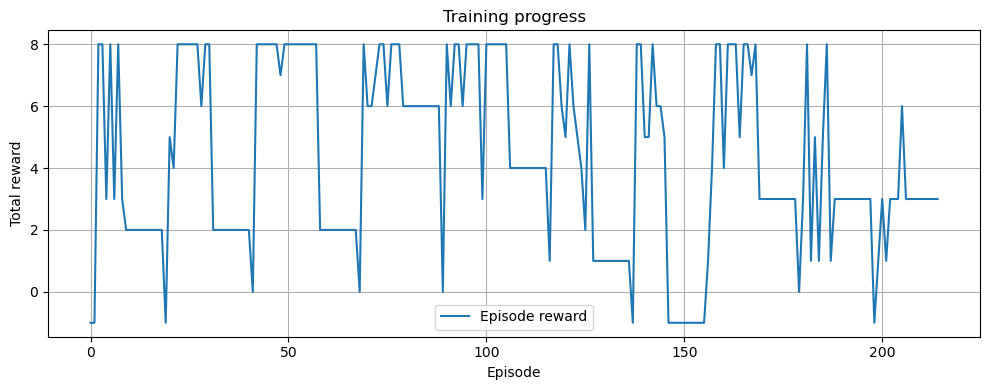

2025-04-29 21:55:23 [info     ] Model parameters are saved to d3rlpy_logs/DQN_online_20250429215413/model_10000.d3
2025-04-29 21:55:23 [info     ] DQN_online_20250429215413: epoch=10 step=10000 epoch=10 metrics={'time_inference': 0.0007791574001312256, 'time_environment_step': 0.0004162135124206543, 'rollout_return': 2.5, 'time_sample_batch': 0.0004814577102661133, 'time_algorithm_update': 0.004695136785507202, 'loss': 0.005145985453622415, 'time_step': 0.006423325300216675, 'evaluation': 3.0} step=10000
2025-04-29 21:55:23 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-04-29 21:55:23 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-04-29 21:55:23 [info     ] Action size has been automatically determined. action_

In [2]:
transitions = []
episode_rewards = []
current_reward = 0

class PogemaD3RLWrapper(gym.Env):
    def __init__(self, config):
        super().__init__()
        self.base_env = pogema_v0(config)
        self.raw_env = AnimationMonitor(self.base_env)
        self.action_space = self.raw_env.action_space

        dummy_result = self.raw_env.reset()
        dummy_obs = dummy_result[0] if isinstance(dummy_result, tuple) else dummy_result
        obs_sample = np.array(dummy_obs[0]).flatten().astype(np.float32)

        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=obs_sample.shape, dtype=np.float32
        )

        self.last_pos = self.raw_env.grid.get_agents_xy()[0]
        self.target_pos = self.raw_env.grid.get_targets_xy()[0]
        self.prev_obs = None
        self.plot_rewards = plot_rewards.__get__(self)

        self.save_animation = self.raw_env.save_animation

    def reset(self):
        global current_reward
        current_reward = 0
        result = self.raw_env.reset()
        obs = result[0] if isinstance(result, tuple) else result
        self.last_pos = self.raw_env.grid.get_agents_xy()[0]
        self.target_pos = self.raw_env.grid.get_targets_xy()[0]
        flattened = self.flatten_obs(obs[0])
        self.prev_obs = flattened
        return flattened, {}

    def step(self, action):
        global current_reward, episode_rewards

        obs, _, terminated, truncated, _ = self.raw_env.step([action])
        current_pos = self.raw_env.grid.get_agents_xy()[0]
        old_dist = self.manhattan(self.last_pos, self.target_pos)
        new_dist = self.manhattan(current_pos, self.target_pos)
        reward = old_dist - new_dist
        self.last_pos = current_pos
        next_obs = self.flatten_obs(obs[0])
        done = terminated[0] or truncated[0]

        transitions.append({
            "obs": self.prev_obs,
            "act": action,
            "rew": reward,
            "next_obs": next_obs,
            "done": done
        })

        self.prev_obs = next_obs
        current_reward += reward

        if done:
            episode_rewards.append(current_reward)
            current_reward = 0
            if len(episode_rewards) % 5 == 0:
                self.plot_rewards()

        return next_obs, reward, terminated[0], truncated[0], {}

    def flatten_obs(self, obs):
        return np.array(obs).flatten().astype(np.float32)

    def manhattan(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

def plot_rewards(self):
    clear_output(wait=True)
    plt.figure(figsize=(10, 4))
    plt.plot(episode_rewards, label="Episode reward")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("Training progress")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

config = GridConfig(num_agents=1,
                    size=15,
                    density=0.4,
                    seed=69,
                    max_episode_steps=128,
                    obs_radius=5)

save_path = "content"

env = PogemaD3RLWrapper(config)

dqn = DQNConfig(
    learning_rate=1e-3,
    target_update_interval=1000
).create(device="cuda" if torch.cuda.is_available() else "cpu")

buffer = create_fifo_replay_buffer(limit=50000, env=env)

dqn.fit_online(
    env,
    buffer,
    explorer=d3rlpy.algos.ConstantEpsilonGreedy(epsilon=0.3),
    n_steps=10000,
    n_steps_per_epoch=1000,
    eval_env=env,
)

observations = np.array([t["obs"] for t in transitions], dtype=np.float32)
actions = np.array([t["act"] for t in transitions])
rewards = np.array([t["rew"] for t in transitions], dtype=np.float32)
terminals = np.array([t["done"] for t in transitions], dtype=bool)

dataset = MDPDataset(
    observations=observations,
    actions=actions,
    rewards=rewards,
    terminals=terminals
)

dataset.dump(save_path + "optimal_dataset.h5")

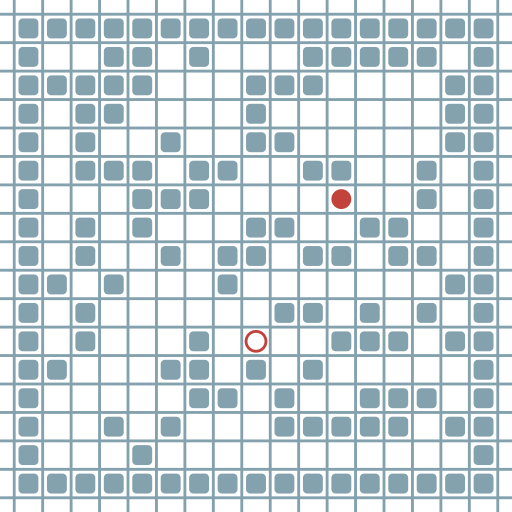

In [3]:
env.save_animation("render.svg")
display(SVG("render.svg"))

Обучение не стабильное, награда очень редко опускается ниже нуля

## CQL

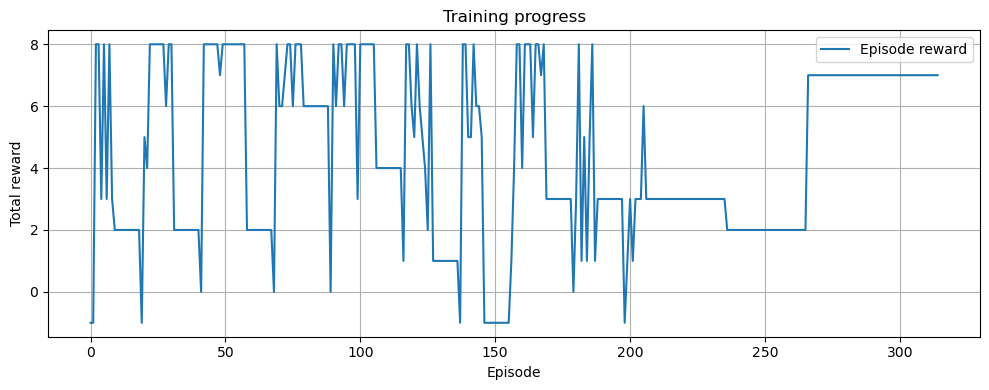

2025-04-29 21:56:10 [info     ] DiscreteCQL_20250429215524: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.00048708724975585937, 'time_algorithm_update': 0.003274421215057373, 'loss': 2.1288243169784544, 'td_loss': 0.6652292901305482, 'conservative_loss': 1.463595028400421, 'time_step': 0.003835405111312866, 'environment': 7.0} step=10000
2025-04-29 21:56:10 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20250429215524/model_10000.d3


[(1,
  {'time_sample_batch': 0.00046594953536987306,
   'time_algorithm_update': 0.0037992115020751955,
   'loss': 2.232152742743492,
   'td_loss': 0.7186592396646738,
   'conservative_loss': 1.513493504166603,
   'time_step': 0.004346046924591064,
   'environment': 3.0}),
 (2,
  {'time_sample_batch': 0.0004928796291351318,
   'time_algorithm_update': 0.0024495277404785157,
   'loss': 2.1411080842018126,
   'td_loss': 0.6574512776471675,
   'conservative_loss': 1.4836568077802659,
   'time_step': 0.0030127284526824953,
   'environment': 3.0}),
 (3,
  {'time_sample_batch': 0.0004924895763397216,
   'time_algorithm_update': 0.0032192244529724123,
   'loss': 2.110111779928207,
   'td_loss': 0.6315505958339199,
   'conservative_loss': 1.4785611840486526,
   'time_step': 0.003781634330749512,
   'environment': 2.0}),
 (4,
  {'time_sample_batch': 0.00048266577720642087,
   'time_algorithm_update': 0.003368471384048462,
   'loss': 2.203178957223892,
   'td_loss': 0.7218235850874335,
   'conse

In [4]:
dataset = joblib.load(save_path + "dataset_3.d3")

cql = d3rlpy.algos.DiscreteCQLConfig().create(device='cpu')

cql.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        'environment': d3rlpy.metrics.EnvironmentEvaluator(env),
    },
)

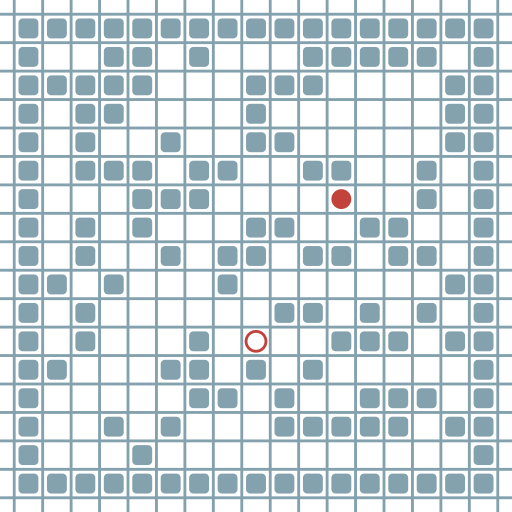

In [5]:
env.save_animation("render.svg")
display(SVG("render.svg"))

Средняя награда стазу вырасла. Возможно, улучшение будет заметнее при большем количестве шагов

## DiscreteBCQ

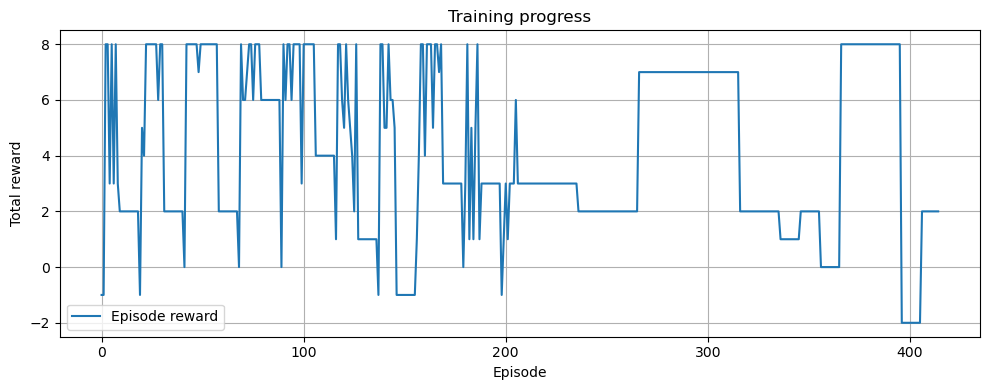

2025-04-29 21:57:32 [info     ] DiscreteBCQ_20250429215610: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.0008160927295684814, 'time_algorithm_update': 0.005532038927078247, 'loss': 6.570744704961776, 'td_loss': 3.7071032742932437, 'imitator_loss': 2.863641434907913, 'time_step': 0.006427431344985962, 'environment': 2.0} step=10000
2025-04-29 21:57:32 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteBCQ_20250429215610/model_10000.d3


[(1,
  {'time_sample_batch': 0.000866887092590332,
   'time_algorithm_update': 0.006152791738510132,
   'loss': 3.2086840035915376,
   'td_loss': 0.34557357709045755,
   'imitator_loss': 2.863110429763794,
   'time_step': 0.007085413932800293,
   'environment': 2.0}),
 (2,
  {'time_sample_batch': 0.000858140230178833,
   'time_algorithm_update': 0.006169430732727051,
   'loss': 4.07122852563858,
   'td_loss': 1.208031509225606,
   'imitator_loss': 2.863197023868561,
   'time_step': 0.007103821754455566,
   'environment': 2.0}),
 (3,
  {'time_sample_batch': 0.0008746497631072998,
   'time_algorithm_update': 0.0054476804733276365,
   'loss': 3.9200975253582,
   'td_loss': 1.0557730479112362,
   'imitator_loss': 2.864324475288391,
   'time_step': 0.006388505697250366,
   'environment': 1.0}),
 (4,
  {'time_sample_batch': 0.0008754024505615235,
   'time_algorithm_update': 0.00639261531829834,
   'loss': 3.4377504093647,
   'td_loss': 0.5762473571919836,
   'imitator_loss': 2.86150305247306

In [6]:
save_path = "content"

env = PogemaD3RLWrapper(config)


dataset = joblib.load(save_path + "dataset_3.d3")

bcq = DiscreteBCQConfig(
    batch_size=64,
    gamma=0.99,
    learning_rate=3e-4,
    n_critics=2,
    action_flexibility=0.1,
    beta=0.5,
    target_update_interval=1000
).create(device='cpu')

bcq.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        'environment': EnvironmentEvaluator(env),
    },
)


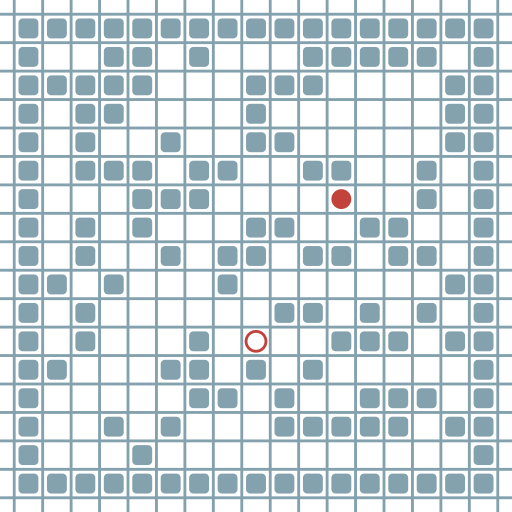

In [7]:
env.save_animation("render.svg")
display(SVG("render.svg"))

С этим алгоритмом, награда сразу достигла максимума, и держалась почти до конца. Возможно, не хватило шагов обучения. Очень хорошая тенденция.

## BC

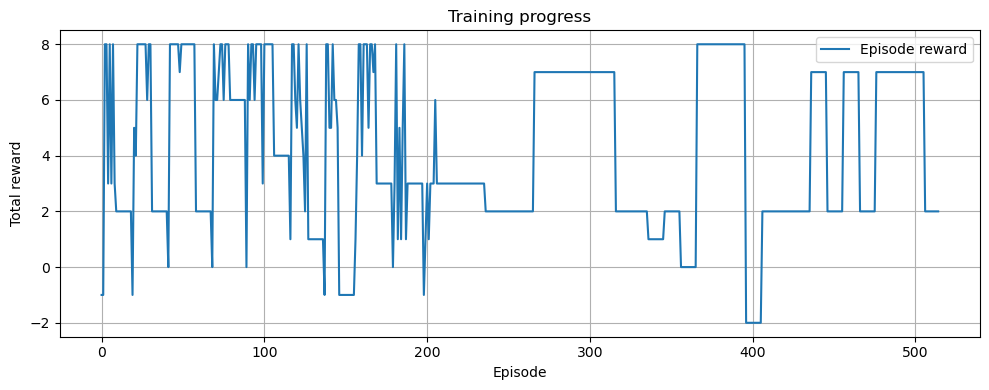

2025-04-29 21:58:33 [info     ] DiscreteBC_20250429215732: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.0007706077098846436, 'time_algorithm_update': 0.0036212849617004396, 'loss': 2.8524385929107665, 'time_step': 0.0044274735450744625, 'environment': 2.0} step=10000
2025-04-29 21:58:33 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteBC_20250429215732/model_10000.d3


[(1,
  {'time_sample_batch': 0.0007709550857543945,
   'time_algorithm_update': 0.004275482416152954,
   'loss': 2.857646888971329,
   'time_step': 0.00508230447769165,
   'environment': 2.0}),
 (2,
  {'time_sample_batch': 0.0008144042491912842,
   'time_algorithm_update': 0.004013333797454834,
   'loss': 2.8551121392250063,
   'time_step': 0.004864593267440796,
   'environment': 2.0}),
 (3,
  {'time_sample_batch': 0.0007917256355285644,
   'time_algorithm_update': 0.0038263113498687744,
   'loss': 2.8537265565395353,
   'time_step': 0.0046536347866058345,
   'environment': 7.0}),
 (4,
  {'time_sample_batch': 0.0007870564460754395,
   'time_algorithm_update': 0.0024764978885650634,
   'loss': 2.8535641930103304,
   'time_step': 0.0032998716831207277,
   'environment': 2.0}),
 (5,
  {'time_sample_batch': 0.000787341833114624,
   'time_algorithm_update': 0.0038739683628082277,
   'loss': 2.8535565586090086,
   'time_step': 0.004698691844940185,
   'environment': 7.0}),
 (6,
  {'time_samp

In [8]:
save_path = "content"
device = "cuda" if torch.cuda.is_available() else "cpu"


dataset = joblib.load(save_path + "dataset_3.d3")


config = GridConfig(
    num_agents=1,
    size=15,
    density=0.4,
    seed=69,
    max_episode_steps=128,
    obs_radius=5
)
env = PogemaD3RLWrapper(config)


encoder_factory = VectorEncoderFactory(
    hidden_units=[256, 256],
    activation="relu",
    use_batch_norm=False,
    dropout_rate=None,
    exclude_last_activation=False
)


bc = DiscreteBCConfig(
    batch_size=64,
    learning_rate=1e-3,
    encoder_factory=encoder_factory
).create(device=device)


bc.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        "environment": EnvironmentEvaluator(env),
    },
    show_progress=True
)



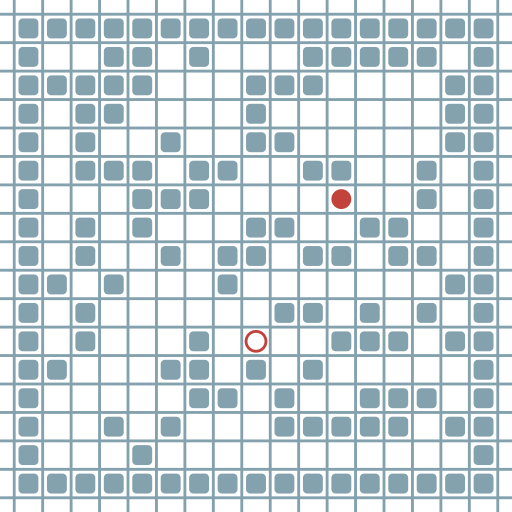

In [9]:
env.save_animation("render.svg")
display(SVG("render.svg"))

Стало менее стабильно, и максимальная награда немного упала. По анимации видно, что мы почти добрались цели

## Датасет с субоптимальной стратегией

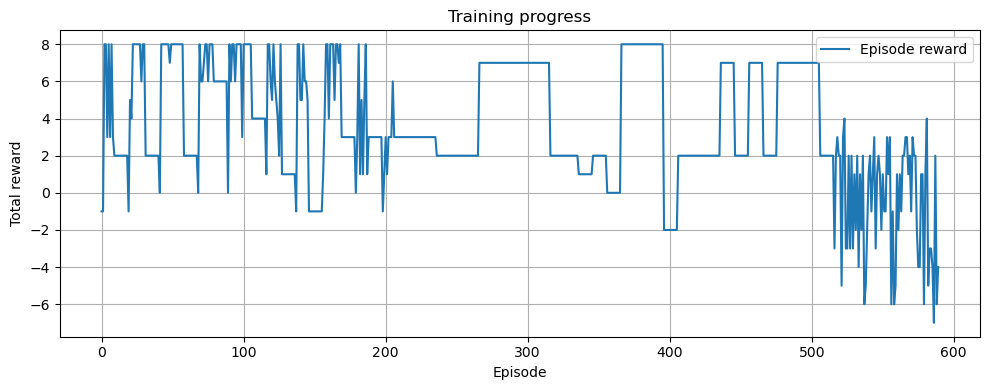

2025-04-29 21:58:37 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-04-29 21:58:37 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-04-29 21:58:37 [info     ] Action size has been automatically determined. action_size=5
2025-04-29 21:58:37 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-04-29 21:58:37 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-04-29 21:58:37 [info     ] Action size has been automatically determined. action_size=5


['contentdataset_combined.d3']

In [10]:
# 1. Загрузить «хороший» датасет

buf = joblib.load("contentdataset_3.d3")
good_ds = buf.to_mdp_dataset() if hasattr(buf, "to_mdp_dataset") else buf


# 2. Извлечь массивы из эпизодов

obs_segs, act_segs, rew_segs, term_segs = [], [], [], []
for ep in good_ds.episodes:
    obs_segs.append(np.asarray(ep.observations, dtype=np.float32))
    act_segs.append(np.asarray(ep.actions, dtype=np.int64).reshape(-1, 1))
    rew_segs.append(np.asarray(ep.rewards, dtype=np.float32))
    term = np.zeros(len(ep.rewards), dtype=np.float32)
    term[-1] = 1.0
    term_segs.append(term)

obs_good  = np.concatenate(obs_segs, axis=0)
act_good  = np.concatenate(act_segs, axis=0)
rew_good  = np.concatenate(rew_segs, axis=0)
term_good = np.concatenate(term_segs, axis=0)


# 3. Сгенерировать случайную стратегию

config = GridConfig(
    num_agents=1,
    size=15,
    density=0.4,
    seed=69,
    max_episode_steps=128,
    obs_radius=5
)
env = PogemaD3RLWrapper(config)

n_steps = 10_000
obs_buf, act_buf, rew_buf, term_buf = [], [], [], []

ret = env.reset()
obs = ret[0] if isinstance(ret, tuple) else ret
obs = np.asarray(obs).reshape(-1)

for _ in range(n_steps):
    a = env.action_space.sample()
    result = env.step(a)
    if len(result) == 5:
        next_obs, r, terminated, truncated, _ = result
        done = terminated or truncated
    else:
        next_obs, r, done, _ = result

    next_obs = np.asarray(next_obs).reshape(-1)
    obs_buf.append(obs)
    act_buf.append([a])
    rew_buf.append([r])
    term_buf.append([float(done)])

    if done:
        ret = env.reset()
        obs = ret[0] if isinstance(ret, tuple) else ret
        obs = np.asarray(obs).reshape(-1)
    else:
        obs = next_obs

obs_rand  = np.array(obs_buf, dtype=np.float32)
act_rand  = np.array(act_buf, dtype=np.int64)
rew_rand  = np.array(rew_buf, dtype=np.float32).reshape(-1)
term_rand = np.array(term_buf, dtype=np.float32).reshape(-1)

random_ds = MDPDataset(obs_rand, act_rand, rew_rand, term_rand)
joblib.dump(random_ds, "contentdataset_random.d3")


# 4. Объединить оба датасета

rew_good = rew_good.reshape(-1)
rew_rand = rew_rand.reshape(-1)
term_good = term_good.reshape(-1)
term_rand = term_rand.reshape(-1)


obs_comb  = np.concatenate([obs_good,  obs_rand ], axis=0)
act_comb  = np.concatenate([act_good,  act_rand ], axis=0)
rew_comb  = np.concatenate([rew_good,  rew_rand ], axis=0)
term_comb = np.concatenate([term_good, term_rand], axis=0)

combined_ds = MDPDataset(obs_comb, act_comb, rew_comb, term_comb)
joblib.dump(combined_ds, "contentdataset_combined.d3")


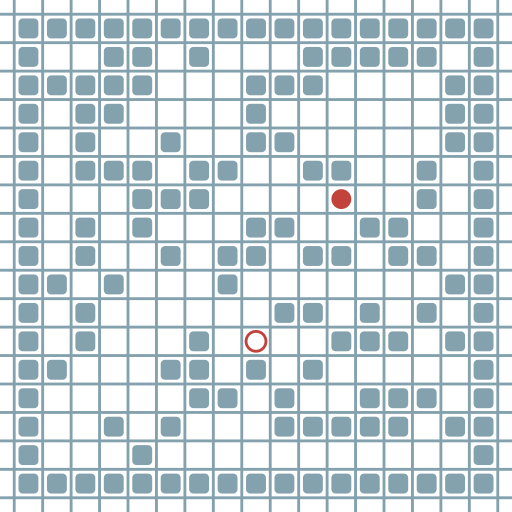

In [11]:
env.save_animation("render.svg")
display(SVG("render.svg"))

На субоптимальных результат тоже получился субоптимальный, что неудивительно.На анимации видно случайное топтание на месте.

## Сбор демонстрационных данных (offline + online) с фильтрацией по награде

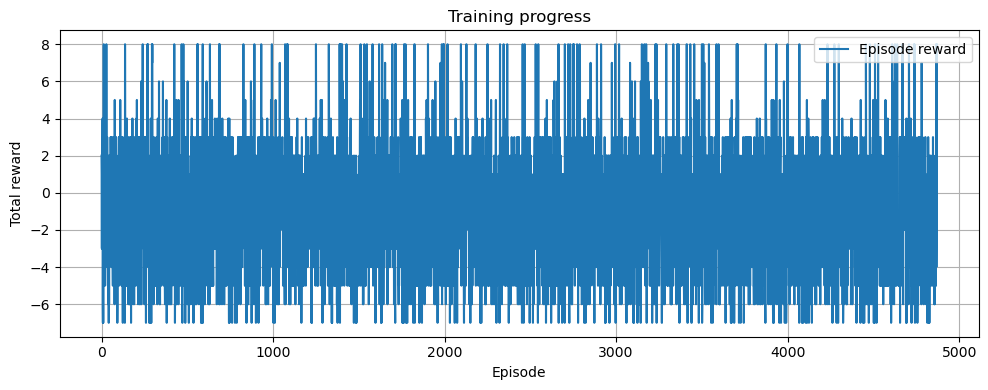

In [12]:
transitions = []
episode_rewards = []
episode_buffer = []
all_episodes = []

current_reward = 0


buf = joblib.load("contentdataset_3.d3")
good_ds = buf.to_mdp_dataset() if hasattr(buf, "to_mdp_dataset") else buf


obs_segs, act_segs, rew_segs, term_segs = [], [], [], []
for ep in good_ds.episodes:
    obs_segs.append(np.asarray(ep.observations, dtype=np.float32))
    act_segs.append(np.asarray(ep.actions, dtype=np.int64).reshape(-1, 1))
    rew_segs.append(np.asarray(ep.rewards, dtype=np.float32))
    term = np.zeros(len(ep.rewards), dtype=np.float32)
    term[-1] = 1.0
    term_segs.append(term)

obs_good  = np.concatenate(obs_segs, axis=0)
act_good  = np.concatenate(act_segs, axis=0)
rew_good  = np.concatenate(rew_segs, axis=0)
term_good = np.concatenate(term_segs, axis=0)


config = GridConfig(
    num_agents=1,
    size=15,
    density=0.4,
    seed=69,
    max_episode_steps=128,
    obs_radius=5
)
env = PogemaD3RLWrapper(config)

n_steps = 10_000
obs_buf, act_buf, rew_buf, term_buf = [], [], [], []

episode_obs, episode_act, episode_rew = [], [], []
total_reward = 0
steps_collected = 0

ret = env.reset()
obs = ret[0] if isinstance(ret, tuple) else ret
obs = np.asarray(obs).reshape(-1)

while steps_collected < n_steps:
    a = env.action_space.sample()
    result = env.step(a)
    if len(result) == 5:
        next_obs, r, terminated, truncated, _ = result
        done = terminated or truncated
    else:
        next_obs, r, done, _ = result

    next_obs = np.asarray(next_obs).reshape(-1)

    episode_obs.append(obs)
    episode_act.append([a])
    episode_rew.append([r])
    total_reward += r

    if done:
        if total_reward > 7:  # ← фильтрация по суммарному вознаграждениею
            for i in range(len(episode_obs)):
                obs_buf.append(episode_obs[i])
                act_buf.append(episode_act[i])
                rew_buf.append(episode_rew[i])
                term_buf.append([1.0 if i == len(episode_obs)-1 else 0.0])
            steps_collected += len(episode_obs)

        # сброс эпизода
        episode_obs.clear()
        episode_act.clear()
        episode_rew.clear()
        total_reward = 0
        ret = env.reset()
        obs = ret[0] if isinstance(ret, tuple) else ret
        obs = np.asarray(obs).reshape(-1)
    else:
        obs = next_obs



In [13]:
obs_rand  = np.array(obs_buf, dtype=np.float32)
act_rand  = np.array(act_buf, dtype=np.int64)
rew_rand  = np.array(rew_buf, dtype=np.float32).reshape(-1)
term_rand = np.array(term_buf, dtype=np.float32).reshape(-1)

random_ds = MDPDataset(obs_rand, act_rand, rew_rand, term_rand)
joblib.dump(random_ds, "contentdataset_random.d3")


rew_good = rew_good.reshape(-1)
rew_rand = rew_rand.reshape(-1)
term_good = term_good.reshape(-1)
term_rand = term_rand.reshape(-1)


obs_comb  = np.concatenate([obs_good,  obs_rand ], axis=0)
act_comb  = np.concatenate([act_good,  act_rand ], axis=0)
rew_comb  = np.concatenate([rew_good,  rew_rand ], axis=0)
term_comb = np.concatenate([term_good, term_rand], axis=0)

combined_ds = MDPDataset(obs_comb, act_comb, rew_comb, term_comb)
joblib.dump(combined_ds, "contentdataset_combined.d3")

2025-04-29 22:02:37 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-04-29 22:02:37 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-04-29 22:02:37 [info     ] Action size has been automatically determined. action_size=5
2025-04-29 22:02:37 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-04-29 22:02:37 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-04-29 22:02:37 [info     ] Action size has been automatically determined. action_size=5


['contentdataset_combined.d3']

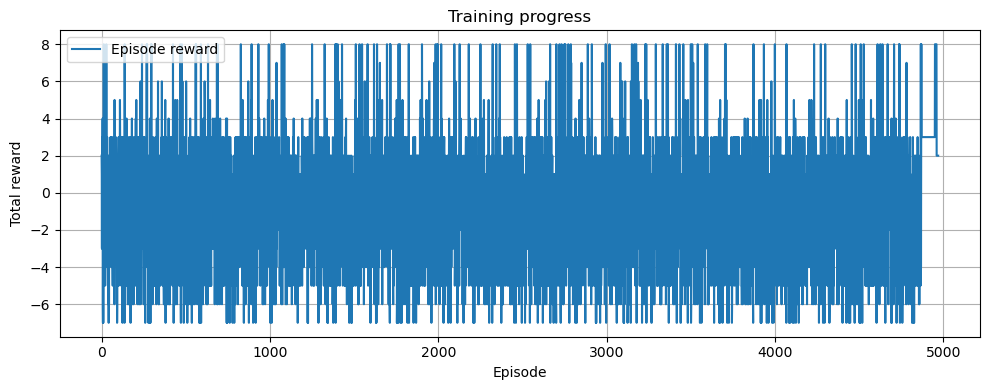

2025-04-29 22:03:25 [info     ] DiscreteCQL_20250429220238: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.000512216567993164, 'time_algorithm_update': 0.0034081029891967775, 'loss': 1.7533008170127868, 'td_loss': 0.18178151757502928, 'conservative_loss': 1.5715193009376527, 'time_step': 0.003998312711715698, 'environment': 2.0} step=10000
2025-04-29 22:03:25 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20250429220238/model_10000.d3


[(1,
  {'time_sample_batch': 0.0005138156414031983,
   'time_algorithm_update': 0.003271587133407593,
   'loss': 1.8744435032606126,
   'td_loss': 0.28834936483949425,
   'conservative_loss': 1.5860941380262374,
   'time_step': 0.0038590607643127443,
   'environment': 3.0}),
 (2,
  {'time_sample_batch': 0.0005221483707427978,
   'time_algorithm_update': 0.0023041191101074218,
   'loss': 1.7800358819961548,
   'td_loss': 0.1918745667608455,
   'conservative_loss': 1.588161317229271,
   'time_step': 0.0029012303352355957,
   'environment': 3.0}),
 (3,
  {'time_sample_batch': 0.0005043523311614991,
   'time_algorithm_update': 0.003440753936767578,
   'loss': 1.7636477739810943,
   'td_loss': 0.1780546360751614,
   'conservative_loss': 1.5855931372642518,
   'time_step': 0.004026201963424683,
   'environment': 3.0}),
 (4,
  {'time_sample_batch': 0.0005076708793640137,
   'time_algorithm_update': 0.00358309268951416,
   'loss': 1.7901502628326416,
   'td_loss': 0.19715387415327132,
   'cons

In [14]:

dataset = joblib.load(save_path + "dataset_combined.d3")

cql = d3rlpy.algos.DiscreteCQLConfig().create(device='cpu')

cql.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        'environment': d3rlpy.metrics.EnvironmentEvaluator(env),
    },
)

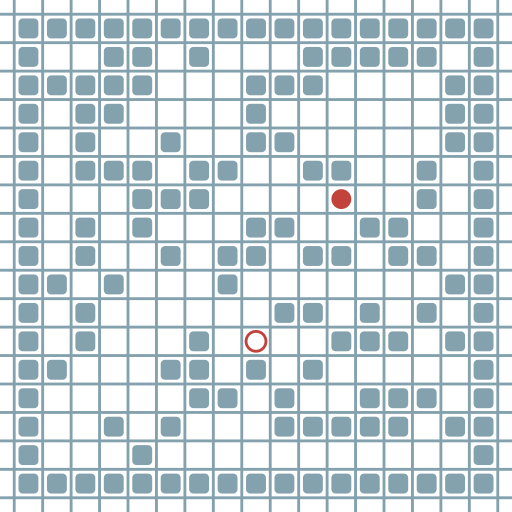

In [15]:
env.save_animation("render.svg")
display(SVG("render.svg"))

Вознаграждение колеблется около нуля. Возможно, надо обучать модель дольше

## BCQ

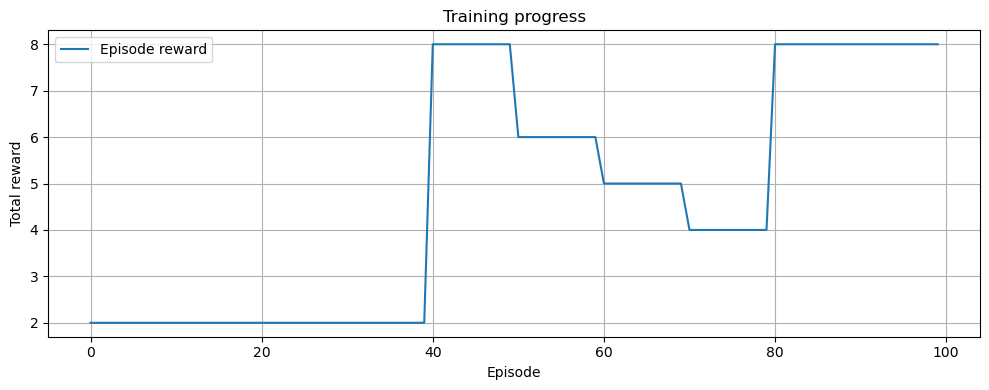

2025-04-29 22:05:12 [info     ] DiscreteBCQ_20250429220326: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.0010589644908905029, 'time_algorithm_update': 0.007901883840560913, 'loss': 3.1880286626815795, 'td_loss': 0.2981216486641206, 'imitator_loss': 2.889907018661499, 'time_step': 0.009044042825698852, 'environment': 8.0} step=10000
2025-04-29 22:05:12 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteBCQ_20250429220326/model_10000.d3


[(1,
  {'time_sample_batch': 0.0010519735813140868,
   'time_algorithm_update': 0.0082007577419281,
   'loss': 3.2622255108356475,
   'td_loss': 0.3691065943250433,
   'imitator_loss': 2.8931189177036285,
   'time_step': 0.009331066846847534,
   'environment': 2.0}),
 (2,
  {'time_sample_batch': 0.000588054895401001,
   'time_algorithm_update': 0.008150612592697143,
   'loss': 3.3380072999000547,
   'td_loss': 0.4470222620191053,
   'imitator_loss': 2.8909850318431856,
   'time_step': 0.00881828761100769,
   'environment': 2.0}),
 (3,
  {'time_sample_batch': 0.0011329784393310546,
   'time_algorithm_update': 0.00856741189956665,
   'loss': 3.2328337252140047,
   'td_loss': 0.3421078401899431,
   'imitator_loss': 2.8907258825302122,
   'time_step': 0.009777864933013917,
   'environment': 2.0}),
 (4,
  {'time_sample_batch': 0.0011084048748016358,
   'time_algorithm_update': 0.008757561922073364,
   'loss': 3.2011791439056396,
   'td_loss': 0.31003313146403527,
   'imitator_loss': 2.89114

In [16]:
transitions = []
episode_rewards = []
episode_buffer = []
all_episodes = []

save_path = "content"

env = PogemaD3RLWrapper(config)


dataset = joblib.load(save_path + "dataset_combined.d3")

bcq = DiscreteBCQConfig(
    batch_size=64,
    gamma=0.99,
    learning_rate=3e-4,
    n_critics=2,
    action_flexibility=0.1,
    beta=0.5,
    target_update_interval=1000
).create(device='cpu')

bcq.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        'environment': EnvironmentEvaluator(env),
    },
)


Метод показал себя наишучшим образом. Обучение прошло в кратчайшие сроки, а процесс обучения был стабильным

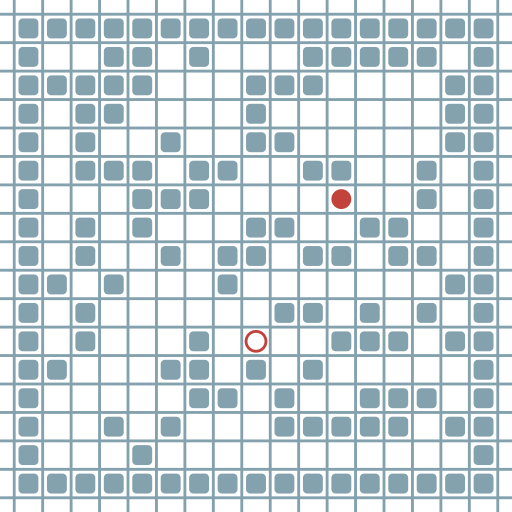

In [17]:
env.save_animation("render.svg")
display(SVG("render.svg"))

## Обучение BC на подготовленном датасете

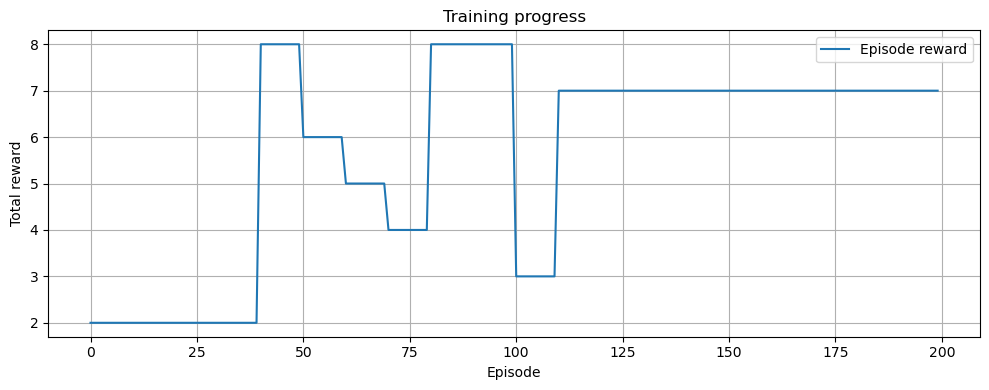

2025-04-29 22:06:15 [info     ] DiscreteBC_20250429220513: epoch=10 step=10000 epoch=10 metrics={'time_sample_batch': 0.0009335823059082031, 'time_algorithm_update': 0.004207133769989014, 'loss': 2.8893943836688996, 'time_step': 0.005177200555801392, 'environment': 7.0} step=10000
2025-04-29 22:06:15 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteBC_20250429220513/model_10000.d3


[(1,
  {'time_sample_batch': 0.0009170916080474854,
   'time_algorithm_update': 0.003941827535629273,
   'loss': 2.8920407989025114,
   'time_step': 0.004895222425460815,
   'environment': 3.0}),
 (2,
  {'time_sample_batch': 0.0008861653804779053,
   'time_algorithm_update': 0.0038352158069610595,
   'loss': 2.890287699460983,
   'time_step': 0.004757008075714111,
   'environment': 7.0}),
 (3,
  {'time_sample_batch': 0.0009177234172821044,
   'time_algorithm_update': 0.003833533763885498,
   'loss': 2.890057445526123,
   'time_step': 0.00478756594657898,
   'environment': 7.0}),
 (4,
  {'time_sample_batch': 0.0008920338153839111,
   'time_algorithm_update': 0.003641064167022705,
   'loss': 2.8894310369491576,
   'time_step': 0.004569055318832398,
   'environment': 7.0}),
 (5,
  {'time_sample_batch': 0.000908552885055542,
   'time_algorithm_update': 0.004192172050476074,
   'loss': 2.889605005502701,
   'time_step': 0.0051371088027954105,
   'environment': 7.0}),
 (6,
  {'time_sample_ba

In [18]:
ave_path = "content"
device = "cuda" if torch.cuda.is_available() else "cpu"


dataset = joblib.load(save_path + "dataset_combined.d3")


config = GridConfig(
    num_agents=1,
    size=15,
    density=0.4,
    seed=69,
    max_episode_steps=128,
    obs_radius=5
)
env = PogemaD3RLWrapper(config)


encoder_factory = VectorEncoderFactory(
    hidden_units=[256, 256],
    activation="relu",
    use_batch_norm=False,
    dropout_rate=None,
    exclude_last_activation=False
)


bc = DiscreteBCConfig(
    batch_size=64,
    learning_rate=1e-3,
    encoder_factory=encoder_factory
).create(device=device)


bc.fit(
    dataset,
    n_steps=10000,
    n_steps_per_epoch=1000,
    evaluators={
        "environment": EnvironmentEvaluator(env),
    },
    show_progress=True
)



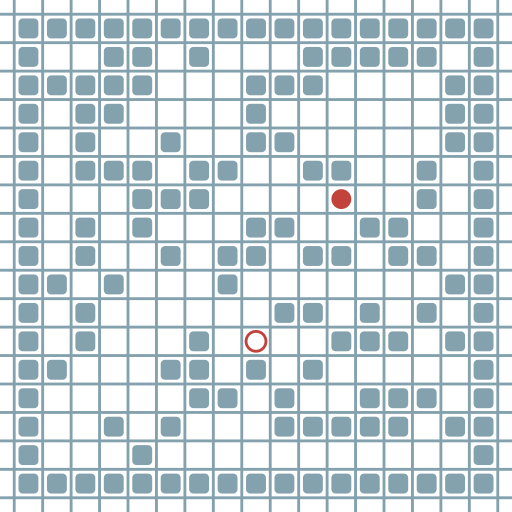

In [19]:
env.save_animation("render.svg")
display(SVG("render.svg"))

Этот метод сразу достиг почти максимальной награды, но так и не достиг максимума. Никакого прогресса.



## Выводы
лучший результат был достигнут на алгоритме DiscreteBCQ. Единственное огорчает провал в последних шагах.
Наихудший - дала стратегия с субоптимальными данными.
Но, при выборе из субоптимального датасета только удачных эпизодов, лучший результат получился у BCQ